# makemore: part 3

# 本课主题：把网络做得更深，并引入【批归一化(Batch Normalization)】技术，让训练更稳定、更快。
# 全程不调用现成的神经网络库，而是手把手自己实现，帮助理解底层原理。

In [2]:
import torch                         # 导入 PyTorch：一个用来做张量计算（可以理解为多维数组运算）的库
import torch.nn.functional as F      # PyTorch 里的函数工具库，后面用它的交叉熵损失函数等
import matplotlib.pyplot as plt      # 导入画图库，用来把训练过程画成曲线图
# %matplotlib inline                   # 让画出来的图直接显示在 notebook 里（而不是弹新窗口）

In [4]:
# 读取 names.txt 文件里的所有人名，每一行是一个人名字，存进一个列表 words 里
words = open('names.txt', 'r').read().splitlines()   # open 打开文件；read() 读出全部文字；splitlines() 按行切分成列表
words[:8]                                            # 只显示前 8 个名字，看看数据长什么样（输出：['emma','olivia',...]）
# words =words[:8]   # （被注释掉的调试代码）如果只想用前 8 个名字快速测试，可以取消这行注释
# words

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)   # 统计总共有多少个人名（输出：8 —— 因为上面被注释掉了，这里其实是在测试状态下）

32033

In [6]:
# 建立【字符表】以及“字符 <-> 数字”的双向映射表（计算机只能处理数字，所以要给每个字符编个号）
chars = sorted(list(set(''.join(words))))   # ''.join(words) 把所有名字拼成一大串；set() 去重得到所有不同字符；sorted() 按字母排序
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi = “字符→数字”字典，编号从 1 开始（0 留给后面的特殊符号 '.'）
stoi['.'] = 0                                # 规定 '.'（表示“名字结束”的特殊符号）编号为 0
itos = {i:s for s,i in stoi.items()}         # itos = “数字→字符”字典，是 stoi 的反向映射，用来把数字翻译回字符
vocab_size = len(itos)                       # 词表大小 = 不同字符的总数
print(itos)                                  # 打印反向映射表，看看每个编号对应哪个字符
print(vocab_size)                            # 打印词表大小（本课数据下是 15）

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
# 构建【训练数据集】：把名字转成网络能学习的“输入 X -> 输出 Y”样本对
block_size = 3 # 上下文长度：用前面 3 个字符来预测下一个字符（像“看前几个字猜下一个字”）

def build_dataset(words):  
  X, Y = [], []                       # X 存“输入（前 3 个字符）”，Y 存“正确答案（下一个字符）"
  
  for w in words:                     # 遍历每一个人名
    context = [0] * block_size        # 一开始“历史窗口”是空的，用 3 个 0（0 代表 '.'，表示还没字符）填充
    for ch in w + '.':                # 遍历名字里的每个字符，最后额外加一个 '.' 表示“名字结束”
      ix = stoi[ch]                   # 把当前字符转成数字编号
      X.append(context)               # 把“当前看到的 3 个字符窗口”记为一条输入
      Y.append(ix)                    # 把“当前字符”记为这条输入对应的正确答案
      context = context[1:] + [ix]    # 窗口向右滑一格：丢掉最旧字符，把新字符加进末尾（像滑动窗口）

  X = torch.tensor(X)                 # 把 X 列表转成 PyTorch 张量（一种能批量计算的数字表格）
  Y = torch.tensor(Y)                 # 把 Y 列表也转成张量
  print(X.shape, Y.shape)             # 打印数据形状（例如 torch.Size([53,3]) 表示 53 条样本，每条有 3 个字符）
  return X, Y

import random
random.seed(42)                       # 设置随机种子，让每次“洗牌”结果一样，保证实验可复现
random.shuffle(words)                 # 把名字列表随机打乱（避免同类名字扎堆）
n1 = int(0.8*len(words))              # 前 80% 的位置，作为训练集的分界点
n2 = int(0.9*len(words))              # 前 90% 的位置，作为验证集的分界点

Xtr,  Ytr  = build_dataset(words)     # 用全部数据构建训练集（本课为了演示，只用训练集训练）
Xdev, Ydev = build_dataset(words[n1:n2])   # 10% 验证集（被注释，正常流程应该用来挑超参数）
Xte,  Yte  = build_dataset(words[n2:])     # 10% 测试集（被注释，正常流程用来最终评估）
Xtr,Ytr                               # 显示构建好的训练数据（X 是 3 字符窗口，Y 是下一个字符）

torch.Size([228146, 3]) torch.Size([228146])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


(tensor([[ 0,  0,  0],
         [ 0,  0, 25],
         [ 0, 25, 21],
         ...,
         [15, 22,  1],
         [22,  1, 14],
         [ 1, 14,  9]]),
 tensor([25, 21,  8,  ..., 14,  9,  0]))

In [8]:
# 重新搭建【多层感知机(MLP)】——一种最基础的神经网络：输入层 -> 隐藏层 -> 输出层
n_embd = 10   # 每个字符被表示成一个 10 维的“嵌入向量”（可以理解成给每个字符分配 10 个数字来描述它的特征）
n_hidden = 200 # 隐藏层里“神经元”的个数（隐藏层就是夹在输入输出之间、负责提取特征的中间层）

g = torch.Generator().manual_seed(2147483647) # 固定随机种子，让每次生成的初始参数都一样（可复现）
C  = torch.randn((vocab_size, n_embd),            generator=g)  # C 是“字符嵌入表”：每个字符一行，每行 10 个随机数
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # W1 是输入到隐藏层的权重矩阵，乘上一个系数让初始数值大小合适
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01  # 隐藏层的偏置（本课用批归一化，所以先不用它）
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01  # W2 是隐藏层到输出层的权重，乘 0.01 让初始预测尽量“保守”
b2 = torch.randn(vocab_size,                      generator=g) * 0      # 输出层偏置，全部初始化为 0

# 【批归一化(BatchNorm)的参数】——批归一化是这节课的核心技巧，下面 4 个量都和它有关
bngain = torch.ones((1, n_hidden))     # “增益”参数 gamma，初始全 1（作用：把归一化后的数据再放大/缩小一点）
bnbias = torch.zeros((1, n_hidden))    # “偏置”参数 beta，初始全 0（作用：把归一化后的数据再平移一点）
bnmean_running = torch.zeros((1, n_hidden))  # “滑动平均均值”，训练时一点点更新，测试时用它代替真实均值
bnstd_running = torch.ones((1, n_hidden))    # “滑动平均标准差”，同理，测试时用它代替真实标准差

parameters = [C, W1, W2, b2, bngain, bnbias]   # 把所有需要训练的参数放进一个列表，方便统一管理
print(sum(p.nelement() for p in parameters)) # 打印参数总数（nelement 是统计一个张量里有几个数字）
for p in parameters:
  p.requires_grad = True   # 告诉 PyTorch：这些参数都要计算“梯度”，才能被优化更新（梯度=告诉参数该往哪个方向调整）

12097


In [9]:
# 【训练循环】——反复“预测 -> 算误差 -> 调整参数”，让网络越学越准
max_steps = 100      # 总共训练 100 步（一轮一轮地学）
batch_size = 32      # 每步随机抽取 32 条样本一起算（叫“小批量”，比一条条算更快更稳）
lossi = []           # 用这个列表记录每一步的损失，最后画成曲线

for i in range(max_steps):            # 循环 100 次
  
  # 1. 随机抽取一个小批量（mini-batch）
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)  # 从训练集里随机挑 32 个“行号”
  Xb, Yb = Xtr[ix], Ytr[ix] # 按行号取出这 32 条样本作为本次的输入 Xb 和答案 Yb
  
  # 2. 前向传播（forward pass）：数据从输入一路算到输出，得出预测结果
  emb = C[Xb]                          # 把 32 条样本里的字符都查表转成“嵌入向量”（每个字符变成 10 个数字）
  embcat = emb.view(emb.shape[0], -1)  # 把每条样本里 3 个字符的向量拼接成一条长向量（3*10=30 个数字）
  # 线性层（Linear）：用权重 W1 对输入做一次“加权求和”，相当于一次线性变换
  hpreact = embcat @ W1 #+ b1          # '@' 是矩阵乘法；hpreact 是隐藏层“激活前”的数值
  # 批归一化层（BatchNorm）—— 核心！把数据“标准化”，让后续训练更稳定
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)   # 求每一列（每个神经元）在本批 32 个样本上的平均值
  bnstdi = hpreact.std(0, keepdim=True)     # 求每一列在本批样本上的标准差（衡量数据分散程度）
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias  # 标准化公式：(x-均值)/标准差，再用 gain/bias 微调
  with torch.no_grad():                     # 下面这段只做记录，不参与求梯度（no_grad 表示不追踪计算）
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani  # 更新“滑动均值”：99.9% 旧值 + 0.1% 本次新值
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi      # 更新“滑动标准差”，用于测试阶段
  # -------------------------------------------------------------
  # 非线性激活（Non-linearity）：用 tanh 函数把数值“压”到 -1~1 之间，给网络增加表达能力
  h = torch.tanh(hpreact)              # h 就是隐藏层最终的输出（经过激活后的结果）
  logits = h @ W2 + b2                 # 输出层：把隐藏层结果再算一次，得到每个字符的“得分”logits
  loss = F.cross_entropy(logits, Yb)   # 损失函数：衡量“预测”和“正确答案”差多远（越小越好）
  
  # 3. 反向传播（backward pass）：计算每个参数对损失的影响（即“梯度”）
  for p in parameters:
    p.grad = None                      # 先把上一次的梯度清零，避免累加干扰
  loss.backward()                      # 自动算出所有参数的梯度
  
  # 4. 更新参数：沿着“梯度相反方向”迈一小步（梯度下降法）
  lr = 0.1 if i < 100000 else 0.01     # 学习率 lr：决定每一步迈多大；这里 100000 步后会调小（本课只跑 100 步）
  for p in parameters:
    p.data += -lr * p.grad             # 参数 = 参数 - 学习率 * 梯度，让损失越来越小

  # 5. 记录训练状态
  if i % 10000 == 0:                   # 每 10000 步打印一次进度
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())    # 把当前损失取对数（log10）存下来，方便画图看整体趋势
  

      0/    100: 3.2802


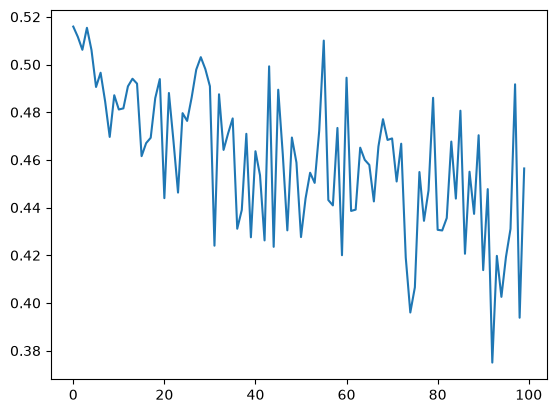

In [10]:
plt.plot(lossi)   # 把训练过程中记录的损失画成曲线，观察损失是否在下降（曲线往下走说明在变好）

In [11]:
# 训练结束后，用【整个训练集】重新测量一遍均值和标准差，作为“最终校准”值
# （训练时用的是每批 32 个样本的小均值，现在用全部数据算一遍，让测试阶段更准确）

with torch.no_grad():                  # 同样不追踪梯度，只做计算
  # 把整个训练集跑一遍前向传播（直到批归一化之前的那一步）
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # 在整个训练集上测量真实的均值和标准差
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [12]:
@torch.no_grad() # 这个装饰器的作用：让函数内部不追踪梯度（测试时不需要，还能省内存、加速）
def split_loss(split):
  x,y = {                       # 根据传入的名字，选择用哪份数据（训练/验证/测试）
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # 把字符查表变成嵌入向量，形状是 (样本数, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # 拼接成 (样本数, block_size * n_embd)
  hpreact = embcat @ W1 # + b1   # 线性层
  # 注意：测试阶段不再用当前批的均值/标准差，而是用训练时保存的“滑动均值/标准差”
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias  # 用滑动统计量做标准化
  h = torch.tanh(hpreact) # 激活函数，得到隐藏层输出 (样本数, n_hidden)
  logits = h @ W2 + b2 # 输出层，得到每个字符的得分 (样本数, vocab_size)
  loss = F.cross_entropy(logits, y)  # 计算损失
  print(split, loss.item())          # 打印“这份数据的名字 + 它的损失值”

split_loss('train')  # 计算并打印训练集损失
split_loss('val')    # 计算并打印验证集损失

train 2.7739057540893555
val 2.773505687713623


## loss log

# 下面是作者逐步优化过程中记录的“损失日志”，每一步都让效果变好了一点（数值越低越好）：

### original:（最初版本）
train 2.1245384216308594
val   2.168196439743042

### fix softmax confidently wrong:（修正 softmax 一开始过于自信的问题）
train 2.07
val   2.13

### fix tanh layer too saturated at init:（修正 tanh 激活层初始就“饱和”的问题）
train 2.0355966091156006
val   2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init:（改用更合理的“凯明初始化”方法）
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer（加入批归一化层后）
train 2.0668270587921143
val 2.104844808578491


In [13]:
# 总结 + 把代码“PyTorch 化”（用面向对象的方式重写，让代码结构更清晰、更像真正的神经网络库）-----------

In [26]:
# 现在训练一个【更深的网络】——把上面的手动代码封装成类，像搭积木一样层层堆叠
# 这里定义的类的接口，和 PyTorch 自带的 nn.Module 用法完全一致，方便理解真正的框架是怎么设计的

class Linear:                        # 定义“线性层”类（相当于把矩阵乘法 + 偏置封装成一个组件）
  
  def __init__(self, fan_in, fan_out, bias=True):  # 初始化：fan_in=输入维度，fan_out=输出维度，bias=是否要偏置
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5  # 随机初始化权重，并除以 sqrt(fan_in) 控制初始大小
    self.bias = torch.zeros(fan_out) if bias else None  # 如果需要偏置就初始化为 0，否则为 None（表示没有）
  
  def __call__(self, x):             # 让这个类可以像函数一样被调用：linear(x) 就会执行下面的前向计算
    self.out = x @ self.weight       # 输入 x 乘上权重矩阵
    if self.bias is not None:
      self.out += self.bias          # 加上偏置
    return self.out                  # 返回结果（同时把结果存到 self.out，方便后面检查）
  
  def parameters(self):              # 返回这一层需要训练的参数列表
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:                   # 定义“批归一化层”类
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):  # dim=维度，eps=防止除零的小数，momentum=滑动更新的快慢
    self.eps = eps                   # 很小的数，避免除以 0
    self.momentum = momentum         # 滑动平均的更新比例（0.1 表示新数据占 10%）
    self.training = True             # 标记当前是否处于“训练模式”（训练和测试行为不同）
    # 需要靠反向传播训练的参数：
    self.gamma = torch.ones(dim)     # 缩放参数 gamma，初始全 1
    self.beta = torch.zeros(dim)     # 平移参数 beta，初始全 0
    # 用“滑动平均”更新的缓冲量（不算真正需要训练的参数）：
    self.running_mean = torch.zeros(dim)  # 滑动均值，初始 0
    self.running_var = torch.ones(dim)    # 滑动方差，初始 1
  
  def __call__(self, x):             # 前向计算
    if self.training:                # 训练时：用当前这一批数据算均值和方差
      xmean = x.mean(0, keepdim=True) # 批均值（对每一列求平均）
      xvar = x.var(0, keepdim=True)   # 批方差（衡量这一列数据有多分散）
    else:                            # 测试时：用训练阶段保存的滑动统计量
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # 标准化：减均值、除以标准差，让数据变成均值0、方差1
    self.out = self.gamma * xhat + self.beta  # 再用 gamma 和 beta 做一次可学习的缩放和平移
    # 训练时更新滑动统计量（为将来测试做准备）
    if self.training:
      with torch.no_grad():          # 更新滑动量时不追踪梯度
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):              # 批归一化层需要训练的参数是 gamma 和 beta
    return [self.gamma, self.beta]

class Tanh:                          # 定义“tanh 激活层”类
  def __call__(self, x):             # 前向：把每个数用 tanh 函数压到 -1~1 之间
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):              # 激活层没有需要训练的参数，返回空列表
    return []

n_embd = 10   # 字符嵌入向量维度
n_hidden = 100 # 隐藏层神经元个数
g = torch.Generator().manual_seed(2147483647) # 固定随机种子，保证可复现

C = torch.randn((vocab_size, n_embd),            generator=g)  # 字符嵌入表
layers = [                          # 把多个层按顺序放进一个列表，组成“深层网络”
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  # 第1组：输入→隐藏，再归一化、激活
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  # 第2组
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  # 第3组
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  # 第4组
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  # 第5组
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),      # 最后一组：输出到每个字符的得分
]
# 下面是“没有批归一化”的旧版网络定义（被注释，用于对比实验）
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():                # 下面的初始化调整不追踪梯度
  # 最后一层：让它的输出“不那么自信”（把 gamma 缩小到 0.1，避免一开始预测太极端）
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1          # （另一种做法：直接缩小权重，被注释）
  # 其他所有层：应用一个“增益系数”
  for layer in layers[:-1]:
    if isinstance(layer, Linear):    # isinstance 判断这一层是不是线性层
      layer.weight *=  1.0 #5/3      # 权重乘 1.0（其实等于没变，注释里的 5/3 是另一种调整方案）

parameters = [C] + [p for layer in layers for p in layer.parameters()]  # 收集全部参数：字符表 C + 每个层的参数
print(sum(p.nelement() for p in parameters)) # 打印参数总数
for p in parameters:
  p.requires_grad = True             # 让所有参数都参与梯度计算（即可被训练）

47024


In [27]:
# 和前面一样的训练流程，只是现在网络更深、步骤更多
max_steps = 20000   # 最多训练 20 万步（下面会提前 break，只演示前 1000 步）
batch_size = 32      # 每批 32 条样本
lossi = []           # 记录损失，画曲线用
ud = []              # 记录“参数更新量 / 参数本身”的比值，用来诊断训练是否健康

for i in range(max_steps):
  
  # 1. 构造小批量
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # 取出本批的输入 X 和答案 Y
  
  # 2. 前向传播：现在只要简单地把数据依次“穿过”每一层即可（封装带来的好处）
  emb = C[Xb]                        # 字符查表变嵌入向量
  x = emb.view(emb.shape[0], -1)     # 拼接成一条长向量
  for layer in layers:               # 依次经过所有层（线性→归一化→激活→...）
    x = layer(x)
  loss = F.cross_entropy(x, Yb)      # 算损失
  
  # 3. 反向传播
  for layer in layers:
    layer.out.retain_grad()          # 保留每层输出的梯度，方便后面可视化诊断（调试用，正式代码可去掉）
  for p in parameters:
    p.grad = None                    # 清零梯度
  loss.backward()                    # 反向传播，自动算梯度
  
  # 4. 更新参数
  lr = 0.1 if i < 150000 else 0.01   # 前 15 万步用较大学习率，之后调小
  for p in parameters:
    p.data += -lr * p.grad           # 梯度下降更新

  # 5. 记录状态
  if i % 10000 == 0:                 # 每 1 万步打印一次
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())  # 记录损失（取对数）
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])  # 记录每个参数的“更新量/参数值”比值，理想应在 1e-3 左右

  # if i >= 1000:
  #   break # 调试用：只跑 1000 步就停，正式训练应删掉这行

      0/  20000: 3.3127
  10000/  20000: 2.2843


layer 2 (      Tanh): mean -0.01, std 0.67, saturated: 6.22%
layer 5 (      Tanh): mean -0.01, std 0.68, saturated: 7.03%
layer 8 (      Tanh): mean -0.00, std 0.69, saturated: 6.12%
layer 11 (      Tanh): mean -0.01, std 0.69, saturated: 5.59%
layer 14 (      Tanh): mean -0.00, std 0.70, saturated: 4.09%


Text(0.5, 1.0, 'activation distribution')

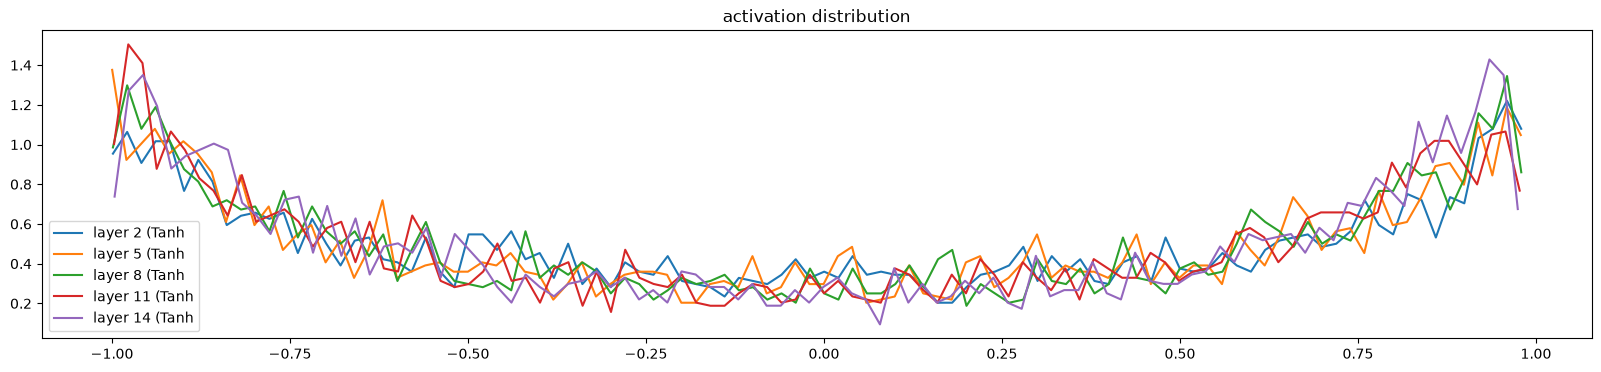

In [28]:
# 可视化每一层 tanh 激活后的数值分布（直方图），检查各层是否健康
plt.figure(figsize=(20, 4)) # 设置画布大小：宽 20、高 4
legends = []                          # 图例标签列表
for i, layer in enumerate(layers[:-1]): # 遍历除输出层外的每一层（用 enumerate 同时拿到序号 i 和层对象）
  if isinstance(layer, Tanh):         # 只看 tanh 激活层
    t = layer.out                     # 取该层输出的数值
    # 打印：层号、均值(mean)、标准差(std)、以及“饱和比例”（接近 ±1 的占比，饱和太多说明网络没学好）
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)  # 用 torch.histogram 计算数据的直方图（密度形式）
    plt.plot(hx[:-1].detach(), hy.detach())    # 画出分布曲线（detach 表示脱离计算图，只取数值）
    legends.append(f'layer {i} ({layer.__class__.__name__}')  # 记录图例
plt.legend(legends);                  # 显示图例
plt.title('activation distribution')  # 设置标题

layer 2 (      Tanh): mean +0.000000, std 2.212713e-03
layer 5 (      Tanh): mean +0.000000, std 2.184166e-03
layer 8 (      Tanh): mean -0.000000, std 2.168348e-03
layer 11 (      Tanh): mean -0.000000, std 2.039002e-03
layer 14 (      Tanh): mean +0.000000, std 2.133751e-03


Text(0.5, 1.0, 'gradient distribution')

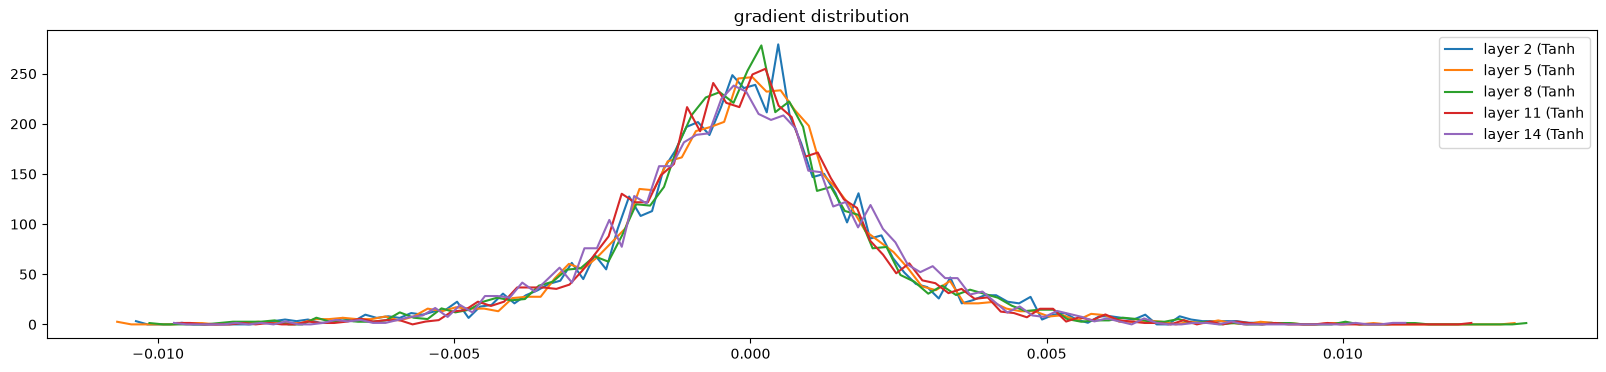

In [29]:
# 可视化每一层 tanh 输出的【梯度】分布，检查梯度是否消失或爆炸（梯度健康，训练才正常）
plt.figure(figsize=(20, 4)) # 画布大小
legends = []
for i, layer in enumerate(layers[:-1]): # 排除输出层
  if isinstance(layer, Tanh):         # 只看 tanh 层
    t = layer.out.grad                # 取该层输出的梯度（.grad 是反向传播后算出来的梯度）
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 8.700239e-03 | grad:data ratio 8.604347e-03
weight  (30, 100) | mean -0.000127 | std 7.557272e-03 | grad:data ratio 3.207407e-02
weight (100, 100) | mean -0.000005 | std 5.044655e-03 | grad:data ratio 3.696759e-02
weight (100, 100) | mean -0.000071 | std 4.683646e-03 | grad:data ratio 3.533537e-02
weight (100, 100) | mean -0.000002 | std 4.480538e-03 | grad:data ratio 3.481270e-02
weight (100, 100) | mean +0.000020 | std 4.155441e-03 | grad:data ratio 3.313932e-02
weight  (100, 27) | mean +0.000097 | std 8.143412e-03 | grad:data ratio 4.584788e-02


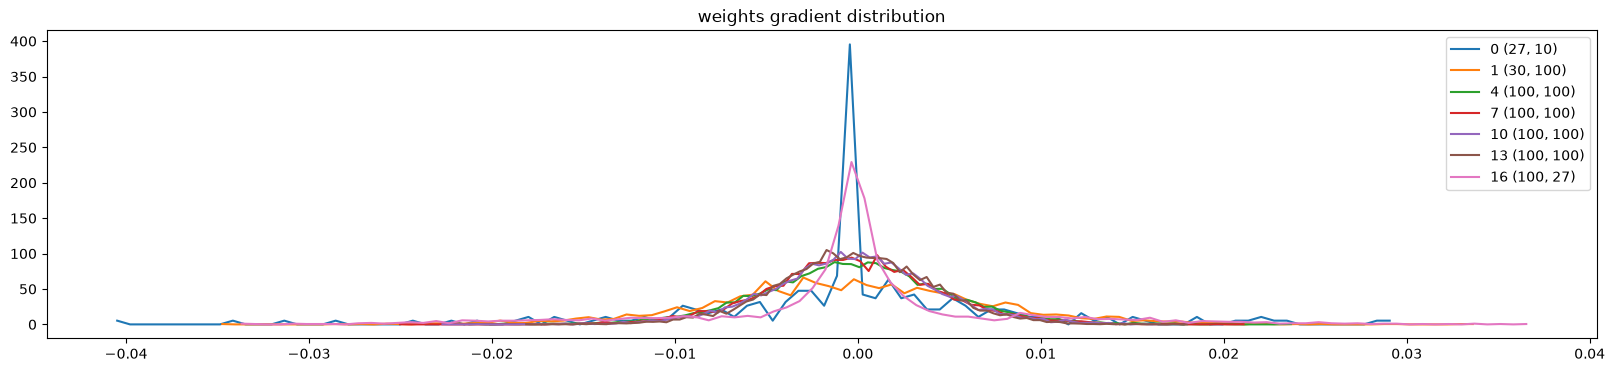

In [30]:
# 可视化所有权重矩阵的【梯度】分布，并打印“梯度:参数”的比值（理想约 1e-3）
plt.figure(figsize=(20, 4)) # 画布大小
legends = []
for i,p in enumerate(parameters):    # 遍历所有参数
  t = p.grad                        # 取该参数的梯度
  if p.ndim == 2:                   # ndim==2 表示是二维的矩阵（即权重矩阵），一维的偏置/增益则跳过
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

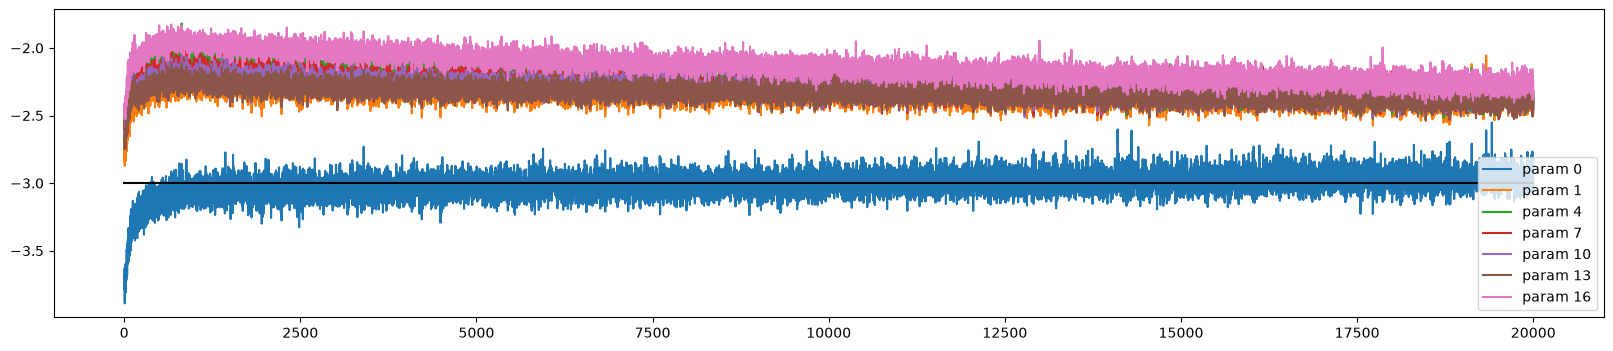

In [31]:
# 画出每个参数“更新量/参数值”比值随训练步数的变化曲线（用于诊断学习率是否合适）
plt.figure(figsize=(20, 4))          # 画布大小
legends = []
for i,p in enumerate(parameters):     # 遍历参数
  if p.ndim == 2:                     # 只看二维的权重矩阵
    plt.plot([ud[j][i] for j in range(len(ud))])  # 画出这个参数在每一步的比值变化（ud 是之前记录的列表）
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # 画一条水平黑线在 -3 处，因为理想比值约 1e-3（即 log10 后约 -3）
plt.legend(legends);                  # 显示图例


In [32]:
@torch.no_grad() # 装饰器：不追踪梯度
def split_loss(split):
  x,y = {                       # 根据名字选择数据集
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # 字符查表变嵌入 (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # 拼接成 (N, block_size * n_embd)
  for layer in layers:          # 数据依次穿过所有层
    x = layer(x)
  loss = F.cross_entropy(x, y)  # 算损失
  print(split, loss.item())     # 打印数据集名和损失

# 把所有层切换到“评估模式”（training=False），这样批归一化会用滑动统计量而不是批统计量
for layer in layers:
  layer.training = False
split_loss('train')            # 打印训练集损失
split_loss('val')              # 打印验证集损失

train 2.157902240753174
val 2.1585495471954346


In [33]:
# 用训练好的模型【生成新名字】：让模型一个字符一个字符地“吐”出新的人名
g = torch.Generator().manual_seed(2147483647 + 10)  # 固定随机种子（用不同种子可得到不同结果）

for _ in range(20):                  # 生成 20 个名字
    
    out = []                          # 存生成的字符编号
    context = [0] * block_size        # 初始上下文窗口，用 0（'.'）填满，相当于“从空白开始”
    while True:                       # 不断循环，直到生成结束符
      # 前向传播：把当前上下文喂给网络
      emb = C[torch.tensor([context])] # 查表得到嵌入 (1, block_size, n_embd)
      x = emb.view(emb.shape[0], -1)   # 拼接成向量
      for layer in layers:             # 依次穿过所有层
        x = layer(x)
      logits = x                       # 输出就是每个字符的得分
      probs = F.softmax(logits, dim=1) # softmax 把得分转成“概率”（加起来等于 1）
      # 按概率随机抽取下一个字符（概率大的字符更可能被选中，带随机性）
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # 滑动窗口：把新字符加进去，同时保留最近 3 个字符作为新上下文
      context = context[1:] + [ix]
      out.append(ix)                   # 记录生成的这个字符
      # 如果抽到了特殊符号 '.'（编号 0），说明名字结束，停止
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # 把编号翻译回字符并拼起来打印（decode 解码）

carmah.
amille.
khi.
mili.
taty.
halaysa.
jazonte.
dellah.
jareei.
nellara.
chaiiv.
kaleig.
dham.
poin.
quinn.
sulin.
alian.
quin.
elo.
dearyxi.


In [34]:
# DONE; BONUS content below, not covered in video

In [35]:
# 用交互式滑块直观演示【批归一化】做了什么：把一个数字挪动，观察它如何被“标准化”到中心

from ipywidgets import interact, interactive, fixed, interact_manual  # 导入交互控件（做可拖动的滑块）
import ipywidgets as widgets        # 控件库
import scipy.stats as stats         # 科学计算库，这里用它的正态分布函数画曲线
import numpy as np                  # 数值计算库

def normshow(x0):                    # 定义一个函数，x0 是滑块控制的那个特殊数值
  
  g = torch.Generator().manual_seed(2147483647+1)  # 固定随机种子
  x = torch.randn(5, generator=g) * 5  # 随机生成 5 个服从正态分布的数，并放大 5 倍（模拟一组数据）
  x[0] = x0 # 把第 0 个数用滑块的值覆盖，方便观察一个“异常值”对标准化的影响
  mu = x.mean()                       # 求这组数据的均值
  sig = x.std()                       # 求标准差
  y = (x - mu)/sig                    # 这就是标准化的核心公式：减均值、除标准差

  plt.figure(figsize=(10, 5))         # 画布大小
  # 画一条横轴参考线
  plt.plot([-6,6], [0,0], 'k')
  # 画出“原始数据”的正态分布曲线（蓝色）
  xx = np.linspace(-6, 6, 100)        # 在 -6 到 6 之间均匀取 100 个点
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')   # 以 mu、sig 为参数画正态分布概率密度曲线
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')      # 再画标准正态分布（均值0、标准差1）曲线（红色）
  # 画一些细线，连接每个“输入点”和它“标准化后”的位置，直观看出数据被拉向中心
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # 用散点画出原始数据（蓝色，在 y=1 位置）和标准化后的数据（红色，在 y=0 位置）
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)                     # 设置 x 轴范围
  # 标题显示当前这组数据的均值和标准差
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));  # 生成滑块（范围 -30 到 30，步长 0.5），拖动即可实时更新图形


interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

In [36]:
# 实验1：观察【纯线性层】在前向和反向传播时，数值的“标准差”会如何变化
# （这个实验证明了：多层线性堆叠会让数值尺度越来越大，导致训练不稳定）

g = torch.Generator().manual_seed(2147483647)  # 固定随机种子

a = torch.randn((1000,1), requires_grad=True, generator=g)          # 输入 a：1000 行 1 列；注释说明 a 的梯度 = b 的转置 @ c 的梯度
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # 权重 b：1000x1000；注释说明 b 的梯度 = c 的梯度 @ a 的转置
c = b @ a                          # c 是线性层的输出：权重 b 乘输入 a
loss = torch.randn(1000, generator=g) @ c   # 构造一个损失：随机向量点乘 c
a.retain_grad()                    # retain_grad 保留 a 的梯度（普通叶子节点之外也能拿到梯度）
b.retain_grad()                    # 保留 b 的梯度
c.retain_grad()                    # 保留 c 的梯度
loss.backward()                    # 反向传播，计算所有梯度
print('a std:', a.std().item())    # 打印输入 a 的标准差
print('b std:', b.std().item())    # 打印权重 b 的标准差
print('c std:', c.std().item())    # 打印输出 c 的标准差（注意它会比输入大很多！说明尺度被放大了）
print('-----')
print('c grad std:', c.grad.std().item())  # c 的梯度的标准差
print('a grad std:', a.grad.std().item())  # a 的梯度的标准差（注意也比 c 的梯度大很多，梯度被放大）
print('b grad std:', b.grad.std().item())  # b 的梯度的标准差

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [37]:
# 实验2：观察【线性层 + 批归一化】后，数值的标准差如何变化（对比实验1会发现输出和梯度尺度都稳定在1附近）

g = torch.Generator().manual_seed(2147483647)

n = 1000                           # 数据规模设为 1000
# 线性层部分 ---
inp = torch.randn(n, requires_grad=True, generator=g)   # 输入 inp：1000 个数
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5   # 权重 w：1000x1000（注释提示还可除以 sqrt(n) 做初始化缩放）
x = w @ inp                        # 线性层输出 x
# 批归一化层部分 ---
xmean = x.mean()                   # 求 x 的均值
xvar = x.var()                     # 求 x 的方差
out = (x - xmean) / torch.sqrt(xvar + 1e-5)  # 标准化：减均值、除以标准差（1e-5 防止除零）
# ----
loss = out @ torch.randn(n, generator=g)  # 构造损失
inp.retain_grad()                  # 保留各变量梯度，方便后面查看
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()                    # 反向传播

print('inp std: ', inp.std().item())   # 输入的标准差
print('w std: ', w.std().item())       # 权重的标准差
print('x std: ', x.std().item())       # 线性层输出的标准差（仍会很大）
print('out std: ', out.std().item())   # 批归一化后的标准差（回到 1 附近！）
print('------')
print('out grad std: ', out.grad.std().item())  # 归一化后输出的梯度标准差
print('x grad std: ', x.grad.std().item())      # 线性层输出的梯度标准差（很小）
print('w grad std: ', w.grad.std().item())      # 权重的梯度标准差
print('inp grad std: ', inp.grad.std().item())  # 输入的梯度标准差（回到 1 附近，说明梯度尺度稳定了）

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953053593635559
